In [1]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()


Saving you-are-bot.zip to you-are-bot.zip


In [17]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    auc,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier, Pool


In [4]:
import zipfile
import os

filename = list(uploaded.keys())[0]

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall('data')


In [5]:
DATA_DIR = Path("/content/data")
TRAIN_JSON = DATA_DIR / "train.json"
TEST_JSON  = DATA_DIR / "test.json"
YTRAIN_CSV = DATA_DIR / "ytrain.csv"
YTEST_CSV  = DATA_DIR / "ytest.csv"

RANDOM_STATE = 42


## Message stats

Преобразуем список сообщений в список их длин, где длина сообщения определяется как количество "слов".

По списку длин сообщений считаем:

- число сообщений
- средняя длина сообщения
- медианная длина
- стандартное отклонение
- максимальная длина
- 90-й перцентиль длины

Полученные статистики добавляются к DataFrame.
В колонке messages хранится список текстов сообщений участника. Для каждой строки сначала вычисляется список длин сообщений, затем по нему - набор агрегированных признаков.

## Ratio features

На основе Message stats конструируются вторичные признаки:

- разность между максимальной и медианной длиной сообщения (характеризует асимметрию и наличие выбросов)
- коэффициент вариации (относительная изменчивость длины сообщений)
- отношение среднего к медиане
- отношение 90-го перцентиля к медиане (насколько хвост распределения отличается от центральной части)
- отношение максимума к 90-му перцентилю (чувствительно к единичным очень длинным сообщениям)
- приближённая оценка общего количества слов, написанных участником.

In [6]:
def get_message_lengths(msg_list):
    if not isinstance(msg_list, list):
        return []
    return [len(re.findall(r"\w+", m.lower())) for m in msg_list]


def extract_stats(lens):

    if len(lens) == 0:
        return dict(
            num_messages=0,
            mean_msg_len=0.0,
            median_msg_len=0.0,
            std_msg_len=0.0,
            max_msg_len=0.0,
            p90_msg_len=0.0,
        )
    arr = np.array(lens)

    return dict(
        num_messages=len(arr),
        mean_msg_len=float(arr.mean()),
        median_msg_len=float(np.median(arr)),
        std_msg_len=float(arr.std()),
        max_msg_len=float(arr.max()),
        p90_msg_len=float(np.percentile(arr, 90)),
    )


def add_message_stats(df):
    df = df.copy()
    lens = df["messages"].apply(get_message_lengths)
    stats = lens.apply(extract_stats)
    stats_df = pd.json_normalize(stats)
    return pd.concat([df, stats_df], axis=1)


def add_ratio_features(df):

    df = df.copy()
    eps = 1e-6

    df["range_msg_len"] = df["max_msg_len"] - df["median_msg_len"]
    df["cv_msg_len"] = df["std_msg_len"] / (df["mean_msg_len"] + eps)
    df["mean_over_median"] = df["mean_msg_len"] / (df["median_msg_len"] + eps)
    df["p90_over_median"] = df["p90_msg_len"] / (df["median_msg_len"] + eps)
    df["max_over_p90"] = df["max_msg_len"] / (df["p90_msg_len"] + eps)
    df["total_words_approx"] = df["num_messages"] * df["mean_msg_len"]

    return df


## Text quality

Извлекаем стилистические признаки, описывающие качество и характер текста участника:
- Количество "?" в тексте
- Количество "!" в тексте
- Доля односимвольных токенов (короткие ответы)
- Доля токенов согласия (да, ok, yes, и т.п.)
- Доля цифр среди всех символов
- Доля не букв/цифр/пробелов


In [7]:
AGREE_TOKENS = {"да", "ок", "ага", "ладно", "угу", "yes", "yeah", "ok", "k"}

def text_quality(text):
    if not isinstance(text, str):
        text = ""
    t = text.strip()
    if not t:
        return dict(
            tq_num_q=0,
            tq_num_exc=0,
            tq_share_short1=0.0,
            tq_share_agree=0.0,
            tq_share_digits=0.0,
            tq_share_nonalpha=0.0,
        )

    num_q = t.count("?")
    num_exc = t.count("!")

    tokens = re.findall(r"\w+", t.lower())
    n_tokens = len(tokens)

    if n_tokens == 0:
        share_short1 = 0.0
        share_agree = 0.0
    else:
        share_short1 = sum(len(tok) == 1 for tok in tokens) / n_tokens
        share_agree = sum(tok in AGREE_TOKENS for tok in tokens) / n_tokens

    chars = list(t)
    n_chars = max(len(chars), 1)

    share_digits = sum(ch.isdigit() for ch in chars) / n_chars
    share_nonalpha = sum(not ch.isalnum() and not ch.isspace() for ch in chars) / n_chars

    return dict(
        tq_num_q=num_q,
        tq_num_exc=num_exc,
        tq_share_short1=share_short1,
        tq_share_agree=share_agree,
        tq_share_digits=share_digits,
        tq_share_nonalpha=share_nonalpha,
    )


def add_text_quality(df):

    feats = df["text"].apply(text_quality)
    feats_df = pd.json_normalize(feats)
    return pd.concat([df, feats_df], axis=1)


## Pairwise features

Конструируем парные фичи, сравнивающие характеристики двух участников (p0 и p1), чтобы зафиксировать относительные различия в стиле общения внутри одного диалога, а не абсолютные.

Нас интересуют:

- разности между участниками по числу сообщений, средней и 90-й перцентильной длине
- отношения соответствующих метрик (p1 / p0).

In [8]:
def add_pairwise_features(df):

    df = df.copy()

    base_cols = [
        "num_messages",
        "mean_msg_len",
        "median_msg_len",
        "std_msg_len",
        "max_msg_len",
        "p90_msg_len",
    ]

    pivot = (
        df.set_index(["dialog_id", "participant_index"])[base_cols]
          .unstack("participant_index")
    )
    pivot.columns = [f"{col}_p{pid}" for col, pid in pivot.columns]

    eps = 1e-6
    pivot["mean_len_diff_p1_minus_p0"] = pivot["mean_msg_len_p1"] - pivot["mean_msg_len_p0"]
    pivot["p90_len_diff_p1_minus_p0"] = pivot["p90_msg_len_p1"] - pivot["p90_msg_len_p0"]
    pivot["num_messages_diff_p1_minus_p0"] = pivot["num_messages_p1"] - pivot["num_messages_p0"]

    pivot["mean_len_ratio_p1_p0"] = pivot["mean_msg_len_p1"] / (pivot["mean_msg_len_p0"] + eps)
    pivot["p90_len_ratio_p1_p0"] = pivot["p90_msg_len_p1"] / (pivot["p90_msg_len_p0"] + eps)

    df = df.merge(pivot.reset_index(), on="dialog_id", how="left")
    return df


Далее строим диалоговые фичи с целью выяснить, как участник встроен в диалог: инициирует ли он разговор, задаёт ли вопросы, повторяет ли чужой текст или подхватывает лексику собеседника.

- Определяем, кто первым говорит в диалоге
- Есть ли вопросительный знак в первом сообщении диалога
- Проверяем, дословно ли участник повторяет предыдущее сообщение собеседника
- Находим долю сообщений участника, которые повторяют предыдущее сообщение другого участника
- Определяем степень "отзеркаливания" лексики собеседника - насколько слова участника схожи с предыдущим сообщением другого участника


In [9]:
def content_word_set(text: str):

    toks = re.findall(r"[A-Za-z0-9_А-Яа-яЁё]+", (text or "").lower())
    return set(toks)


def starter_participant_index(dialog):

    if not dialog or not isinstance(dialog, list):
        return -1
    try:
        return int(dialog[0].get("participant_index"))
    except Exception:
        return -1


def starter_has_qmark(dialog):

    if not dialog or not isinstance(dialog, list):
        return 0
    first_text = (dialog[0].get("text") or "")
    return 1 if "?" in first_text else 0

def is_repeat_of_prev_other(curr_text: str, prev_other_text: str) -> bool:
    if not prev_other_text:
        return False

    def norm(s):
        s = (s or "").lower()
        s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
        s = re.sub(r'[^\w\s]+', ' ', s, flags=re.UNICODE)
        s = re.sub(r'\s+', ' ', s).strip()
        return s

    return norm(curr_text) == norm(prev_other_text)


def repeat_after_other_rate(dialog, pid: int):

    if not dialog or not isinstance(dialog, list):
        return 0.0
    prev_other = None
    repeats = total = 0
    for m in dialog:
        idx = int(m.get("participant_index"))
        text = m.get("text") or ""
        if idx == 1 - pid:
            prev_other = text
        elif idx == pid:
            total += 1
            if is_repeat_of_prev_other(text, prev_other):
                repeats += 1
    return repeats / total if total else 0.0


def avg_overlap_with_prev_other(dialog, pid: int):

    if not dialog or not isinstance(dialog, list):
        return 0.0
    prev_other = None
    sims = []
    for m in dialog:
        idx = int(m.get("participant_index"))
        text = m.get("text") or ""
        if idx == 1 - pid:
            prev_other = text
        elif idx == pid and prev_other:
            a = content_word_set(text)
            b = content_word_set(prev_other)
            U = len(a | b) or 1
            sims.append(len(a & b) / U)
    return float(np.mean(sims)) if sims else 0.0


def build_dialog_interaction_features(json_path: str) -> pd.DataFrame:

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for dialog_id, dialog in data.items():
        dialog_id_str = str(dialog_id)

        starter_pid = starter_participant_index(dialog)
        starter_q = starter_has_qmark(dialog)

        for pid in [0, 1]:
            rep_rate = repeat_after_other_rate(dialog, pid)
            overlap = avg_overlap_with_prev_other(dialog, pid)

            rows.append({
                "dialog_id": dialog_id_str,
                "participant_index": pid,
                "is_starter": 1 if pid == starter_pid else 0,
                "starter_has_qmark": starter_q,
                "repeat_after_other_rate": rep_rate,
                "overlap_prev_other": overlap,
            })

    return pd.DataFrame(rows)


Далее реализуем общий пайплайн feature engineering для train/test участников:
- message stats
- ratios
- text quality
- pairwise features

In [10]:
def enrich_participants(df: pd.DataFrame) -> pd.DataFrame:
    df = add_message_stats(df)
    df = add_ratio_features(df)
    df = add_text_quality(df)
    df = add_pairwise_features(df)
    return df


Строим тренировочный датафрейм.

Для каждого диалога сообщения разделяются по участникам (participant_index = 0 и 1). Каждый участник рассматривается как отдельная строка в датасете и представлен:

- ID диалога
- индексом
- списком сообщений (messages)
- агрегированным текстом (text)
- набором поведенческих и текстовых фич
- таргетом is_bot

Аналогично для тестового, но без таргета.

In [11]:
def build_train_participants(data_file: str, labels_file: str) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_file)
    labels_df["dialog_id"] = labels_df["dialog_id"].astype(str)
    labels_df["participant_index"] = labels_df["participant_index"].astype(str)

    labels_dict = {
        (row["dialog_id"], row["participant_index"]): int(row["is_bot"])
        for _, row in labels_df.iterrows()
    }

    with open(data_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for dialog_id, messages in data.items():
        dialog_id = str(dialog_id)

        p0_msgs = [m["text"] for m in messages if m["participant_index"] == "0"]
        p1_msgs = [m["text"] for m in messages if m["participant_index"] == "1"]

        if (dialog_id, "0") not in labels_dict or (dialog_id, "1") not in labels_dict:
            continue

        rows.append({
            "dialog_id": dialog_id,
            "participant_index": 0,
            "messages": p0_msgs,
            "text": " ".join(p0_msgs),
            "is_bot": labels_dict[(dialog_id, "0")],
        })
        rows.append({
            "dialog_id": dialog_id,
            "participant_index": 1,
            "messages": p1_msgs,
            "text": " ".join(p1_msgs),
            "is_bot": labels_dict[(dialog_id, "1")],
        })

    df = pd.DataFrame(rows)
    df = enrich_participants(df)
    return df


def build_test_participants(data_file: str, info_file: str) -> pd.DataFrame:
    df_info = pd.read_csv(info_file)
    df_info["dialog_id"] = df_info["dialog_id"].astype(str)
    df_info["participant_index"] = df_info["participant_index"].astype(str)

    with open(data_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for _, row in df_info.iterrows():
        dialog_id = str(row["dialog_id"])
        p_idx = row["participant_index"]
        msg_id = row["ID"]

        messages = data[dialog_id]
        msgs = [m["text"] for m in messages if m["participant_index"] == p_idx]

        rows.append({
            "ID": msg_id,
            "dialog_id": dialog_id,
            "participant_index": int(p_idx),
            "messages": msgs,
            "text": " ".join(msgs),
        })

    df = pd.DataFrame(rows)
    df = enrich_participants(df)
    return df


In [56]:
train_participants = build_train_participants(TRAIN_JSON, YTRAIN_CSV)
test_participants  = build_test_participants(TEST_JSON, YTEST_CSV)

train_dialog_feats = build_dialog_interaction_features(TRAIN_JSON)
test_dialog_feats  = build_dialog_interaction_features(TEST_JSON)

train_participants = train_participants.merge(
    train_dialog_feats, on=["dialog_id", "participant_index"], how="left"
)
test_participants = test_participants.merge(
    test_dialog_feats, on=["dialog_id", "participant_index"], how="left"
)


In [57]:
train_participants

,dialog_id,participant_index,messages,text,is_bot,num_messages,mean_msg_len,median_msg_len,std_msg_len,max_msg_len,...,p90_msg_len_p1,mean_len_diff_p1_minus_p0,p90_len_diff_p1_minus_p0,num_messages_diff_p1_minus_p0,mean_len_ratio_p1_p0,p90_len_ratio_p1_p0,is_starter,starter_has_qmark,repeat_after_other_rate,overlap_prev_other
0,dae9e2dae9f840549764f8d9bbbb80f0,0,"[Hello!, Отлично! А твои?, Расскажи теорему]",Hello! Отлично! А твои? Расскажи теорему,0,3,2.000000,2.0,0.816497,3.0,...,2.0,0.000000,-0.8,-1,1.000000,0.714285,1,0,0.0,0.000000
1,dae9e2dae9f840549764f8d9bbbb80f0,1,"[Как дела?, Это круто!]",Как дела? Это круто!,0,2,2.000000,2.0,0.000000,2.0,...,2.0,0.000000,-0.8,-1,1.000000,0.714285,0,0,0.0,0.000000
2,159da0d7937c4c1e84a51f0df7e3ade6,0,"[Привет, никак, оооокккееуу, оууукккии, оооууу...",Привет никак оооокккееуу оууукккии оооуууллкке...,0,7,1.000000,1.0,0.000000,1.0,...,20.0,14.142857,19.0,0,15.142842,19.999980,1,0,0.0,0.000000
3,159da0d7937c4c1e84a51f0df7e3ade6,1,"[Привет! Как я могу помочь тебе сегодня?, Хоро...",Привет! Как я могу помочь тебе сегодня? Хорошо...,1,7,15.142857,15.0,5.303060,26.0,...,20.0,14.142857,19.0,0,15.142842,19.999980,0,0,0.0,0.020408
4,1aed86f082234446951360d00979f0d9,0,"[Привет, Ты бот?]",Привет Ты бот?,0,2,1.500000,1.5,0.500000,2.0,...,3.8,1.500000,1.9,0,1.999999,1.999999,1,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1567,c0cdf02db160429db55ba01895754faf,1,"[привет, как дела?, ну, нормально, а у тебя?, ...","привет, как дела? ну, нормально, а у тебя? хз,...",1,4,5.500000,5.5,1.802776,8.0,...,7.4,1.750000,1.7,0,1.466666,1.298245,0,0,0.0,0.108333
1568,810d22da5d284bb6b2735b9f2233cc94,0,"[привет, 🇬🇳, АХАХАХХАХА]",привет 🇬🇳 АХАХАХХАХА,0,3,0.666667,1.0,0.471405,1.0,...,2.6,1.000000,1.6,0,2.499996,2.599997,1,0,0.0,0.000000
1569,810d22da5d284bb6b2735b9f2233cc94,1,"[гойда, данил иди нах, придурок]",гойда данил иди нах придурок,0,3,1.666667,1.0,0.942809,3.0,...,2.6,1.000000,1.6,0,2.499996,2.599997,0,0,0.0,0.000000
1570,9e58b1e21fe4482eaff89d6f920d757e,0,"[где, что, когда, почему, 20 04, как, где, ско...",где что когда почему 20 04 как где сколько теб...,0,8,1.375000,1.0,0.695971,3.0,...,3.9,0.625000,1.6,0,1.454544,1.695651,1,0,0.0,0.071429


In [59]:
base_num_features = [
    "num_messages", "mean_msg_len", "median_msg_len", "std_msg_len",
    "max_msg_len", "p90_msg_len", "range_msg_len", "cv_msg_len",
    "mean_over_median", "p90_over_median", "max_over_p90",
    "total_words_approx",

    "tq_num_q", "tq_num_exc",
    "tq_share_short1", "tq_share_agree",
    "tq_share_digits", "tq_share_nonalpha",

    "mean_len_diff_p1_minus_p0",
    "p90_len_diff_p1_minus_p0",
    "num_messages_diff_p1_minus_p0",
    "mean_len_ratio_p1_p0",
    "p90_len_ratio_p1_p0",

    "is_starter",
    "starter_has_qmark",
    "repeat_after_other_rate",
    "overlap_prev_other",
]

for df in [train_participants, test_participants]:
    df["text"] = df["text"].fillna("")
    df[base_num_features] = df[base_num_features].fillna(0.0)


## lr proba

Создадим две текстовые stacker-фичи: lr_word_proba и lr_char_proba.

Первая опирается на словесные n-граммы, вторая - на символьные.

Используем StratifiedGroupKFold (5 фолдов) с группировкой по dialog_id:

на каждом фолде обучаем TfidfVectorizer по сырому тексту участников из train-части, преобразуем тексты в TF-IDF матрицы и обучаем LogisticRegression для Word-stacker и Char-stacker по отдельности.

In [60]:
def add_text_stackers_word_char(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    text_col: str = "text",
    target_col: str = "is_bot",
    group_col: str = "dialog_id",
    random_state: int = 42,
    max_features_word: int = 15000,
    max_features_char: int = 60000,
    char_ngram_range: tuple[int, int] = (3, 5),
):
    X_text = train_df[text_col].fillna("")
    y = train_df[target_col].astype(int).values
    groups = train_df[group_col].values

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    oof_word = np.zeros(len(train_df), dtype=float)
    oof_char = np.zeros(len(train_df), dtype=float)
    test_word_folds, test_char_folds = [], []

    for fold, (tr, va) in enumerate(cv.split(X_text, y, groups=groups), 1):
        print(f"\nText stackers fold {fold}...")

        X_tr, X_va = X_text.iloc[tr], X_text.iloc[va]
        y_tr, y_va = y[tr], y[va]

        vec_w = TfidfVectorizer(
            max_features=max_features_word,
            ngram_range=(1, 2),
            min_df=3,
        )
        Xtr_w = vec_w.fit_transform(X_tr)
        Xva_w = vec_w.transform(X_va)

        lr_w = LogisticRegression(max_iter=2000, C=2.0, n_jobs=-1)
        lr_w.fit(Xtr_w, y_tr)

        pred_va_w = lr_w.predict_proba(Xva_w)[:, 1]
        oof_word[va] = pred_va_w
        test_word_folds.append(lr_w.predict_proba(vec_w.transform(test_df[text_col].fillna("")))[:, 1])

        vec_c = TfidfVectorizer(
            analyzer="char",
            max_features=max_features_char,
            ngram_range=char_ngram_range,
            min_df=3,
        )
        Xtr_c = vec_c.fit_transform(X_tr)
        Xva_c = vec_c.transform(X_va)

        lr_c = LogisticRegression(max_iter=2000, C=2.0, n_jobs=-1)
        lr_c.fit(Xtr_c, y_tr)

        pred_va_c = lr_c.predict_proba(Xva_c)[:, 1]
        oof_char[va] = pred_va_c
        test_char_folds.append(lr_c.predict_proba(vec_c.transform(test_df[text_col].fillna("")))[:, 1])

        print(f"  fold word LogLoss = {log_loss(y_va, pred_va_w):.4f}")
        print(f"  fold char LogLoss = {log_loss(y_va, pred_va_c):.4f}")

    print("\nOOF LogLoss word:", log_loss(y, oof_word))
    print("OOF LogLoss char:", log_loss(y, oof_char))

    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df["lr_word_proba"] = oof_word
    test_df["lr_word_proba"] = np.mean(test_word_folds, axis=0)

    train_df["lr_char_proba"] = oof_char
    test_df["lr_char_proba"] = np.mean(test_char_folds, axis=0)

    return train_df, test_df

In [61]:
train_participants, test_participants = add_text_stackers_word_char(
    train_participants, test_participants)

num_features = base_num_features + ["lr_word_proba", "lr_char_proba"]

for df in [train_participants, test_participants]:
    df[num_features] = df[num_features].fillna(0.0)



Text stackers fold 1...
  fold word LogLoss = 0.4692
  fold char LogLoss = 0.4577

Text stackers fold 2...
  fold word LogLoss = 0.4843
  fold char LogLoss = 0.4831

Text stackers fold 3...
  fold word LogLoss = 0.4891
  fold char LogLoss = 0.5003

Text stackers fold 4...
  fold word LogLoss = 0.4980
  fold char LogLoss = 0.5057

Text stackers fold 5...
  fold word LogLoss = 0.4699
  fold char LogLoss = 0.4529

OOF LogLoss word: 0.4820790427370102
OOF LogLoss char: 0.4798909620347185


И наконец обучаем CatBoostClassifier по числовым признакам с использованием StratifiedGroupKFold CV (5 фолдов) и группировкой по dialog_id, чтобы участники из одного диалога не попадали одновременно в train и val.

На каждом фолде:
- делим данные на train/val по индексам
- формируем Pool объекты CatBoost для train/val/test
- обучаем CatBoost на Logloss
- сохраняем вероятности на валидации в массив OOF (out-of-fold), что даёт честную оценку качества;
- считаем метрики.

И создаем итоговые предсказания для test, усредняем,сохраняем сабмит и выводим feature importances для интерпретации вклада признаков.

In [62]:
def train_catboost_cv(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    num_features: list[str],
    target_col: str = "is_bot",
    group_col: str = "dialog_id",
    n_splits: int = 5,
    random_state: int = 42,
    submission_path: str = "catboost_stacked_dialog.csv",
):
    X_num = train_df[num_features]
    y = train_df[target_col].astype(int).values
    groups = train_df[group_col].values

    test_num = test_df[num_features]

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_proba = np.zeros(len(train_df), dtype=float)
    test_probas = []
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_num, y, groups=groups), 1):
        print(f"\nCatBoost fold {fold}...")

        X_tr, X_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        train_pool = Pool(X_tr, label=y_tr)
        val_pool = Pool(X_val, label=y_val)
        test_pool = Pool(test_num)

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="Logloss",
            depth=6,
            learning_rate=0.05,
            iterations=2000,
            l2_leaf_reg=3.0,
            random_seed=random_state,
            border_count=128,
            verbose=200,
            use_best_model=True,
            thread_count=-1,
        )

        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
        )

        val_pred = model.predict_proba(val_pool)[:, 1]
        oof_proba[val_idx] = val_pred

        y_pred = (val_pred >= 0.5).astype(int)

        fold_loss = log_loss(y_val, val_pred)
        fold_auc = roc_auc_score(y_val, val_pred)
        fold_acc = accuracy_score(y_val, y_pred)
        fold_f1 = f1_score(y_val, y_pred)
        fold_prec = precision_score(y_val, y_pred)
        fold_rec = recall_score(y_val, y_pred)

        prec_curve, rec_curve, _ = precision_recall_curve(y_val, val_pred)
        fold_pr_auc = auc(rec_curve, prec_curve)

        print(f"  fold LogLoss:   {fold_loss:.4f}")
        print(f"  fold ROC AUC:   {fold_auc:.4f}")
        print(f"  fold ACC:       {fold_acc:.4f}")
        print(f"  fold F1:        {fold_f1:.4f}")
        print(f"  fold Precision: {fold_prec:.4f}")
        print(f"  fold Recall:    {fold_rec:.4f}")
        print(f"  fold PR AUC:    {fold_pr_auc:.4f}")

        fold_metrics.append({
            "logloss": fold_loss,
            "auc": fold_auc,
            "acc": fold_acc,
            "f1": fold_f1,
            "precision": fold_prec,
            "recall": fold_rec,
            "pr_auc": fold_pr_auc,
        })

        test_pred = model.predict_proba(test_pool)[:, 1]
        test_probas.append(test_pred)

    print("\nOOF LogLoss CatBoost:", log_loss(y, oof_proba))

    metrics_df = pd.DataFrame(fold_metrics)
    print("\n=== Mean CV metrics ===")
    print(metrics_df.mean())

    test_proba_mean = np.mean(test_probas, axis=0)

    submission = pd.DataFrame({
        "ID": test_df["ID"],
        "is_bot": test_proba_mean,
    })
    submission.to_csv(submission_path, index=False)
    print(f"Saved {submission_path}")

    print("\n=== Feature_importances ===")
    feature_importances = model.get_feature_importance(train_pool)
    for name, importance in sorted(zip(num_features, feature_importances), key=lambda x: -x[1]):
        print(f"{name:30s} {importance:.3f}")

    return oof_proba, test_proba_mean, metrics_df


In [63]:
oof_proba_cb, test_proba_cb, metrics_df_cb = train_catboost_cv(
    train_participants,
    test_participants,
    num_features=num_features,
    submission_path="catboost_stacked_lr_char_word.csv",
)



CatBoost fold 1...
0:	learn: 0.6602279	test: 0.6571506	best: 0.6571506 (0)	total: 4.05ms	remaining: 8.09s
200:	learn: 0.1261134	test: 0.2622582	best: 0.2598249 (157)	total: 741ms	remaining: 6.63s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.259824943
bestIteration = 157

Shrink model to first 158 iterations.
  fold LogLoss:   0.2598
  fold ROC AUC:   0.9536
  fold ACC:       0.8924
  fold F1:        0.8350
  fold Precision: 0.8866
  fold Recall:    0.7890
  fold PR AUC:    0.9274

CatBoost fold 2...
0:	learn: 0.6598110	test: 0.6620868	best: 0.6620868 (0)	total: 8.9ms	remaining: 17.8s
200:	learn: 0.1143773	test: 0.3255623	best: 0.3172065 (116)	total: 1.13s	remaining: 10.1s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.3172065135
bestIteration = 116

Shrink model to first 117 iterations.
  fold LogLoss:   0.3172
  fold ROC AUC:   0.9314
  fold ACC:       0.8854
  fold F1:        0.8252
  fold Precision: 0.8095
  fold Recall:    0.8416
  fol

# Для сравнения посмотрим на результаты baseline

In [ ]:
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

import json
import pandas as pd


def load_train_data(data_file: str, labels_file: str):
    all_texts = []
    all_labels = []
    labels_df = pd.read_csv(labels_file)

    labels_df["dialog_id"] = labels_df["dialog_id"].astype(str)
    labels_df["participant_index"] = labels_df["participant_index"].astype(str)
    labels_dict = {
        (row["dialog_id"], row["participant_index"]): int(row["is_bot"])
        for _, row in labels_df.iterrows()
    }

    with open(data_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for dialog_id, messages in data.items():
        dialog_id = str(dialog_id)

        part_0_texts = [
            m["text"] for m in messages if m["participant_index"] == "0"
        ]
        part_1_texts = [
            m["text"] for m in messages if m["participant_index"] == "1"
        ]

        part_0_label = labels_dict[(dialog_id, "0")]
        part_1_label = labels_dict[(dialog_id, "1")]

        text_0 = " ".join(part_0_texts)
        text_1 = " ".join(part_1_texts)

        all_texts.append(text_0)
        all_labels.append(part_0_label)

        all_texts.append(text_1)
        all_labels.append(part_1_label)

    df = pd.DataFrame({"text": all_texts, "is_bot": all_labels})
    return df


def load_test_data(data_file: str, labels_file: str):
    df_info = pd.read_csv(labels_file)

    with open(data_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_texts = []
    ids = []

    for _, row in df_info.iterrows():
        dialog_id = row["dialog_id"]
        participant_index = str(row["participant_index"])
        messages = data[dialog_id]

        texts = [
            m["text"] for m in messages if m["participant_index"] == participant_index
        ]
        combined_text = " ".join(texts)
        all_texts.append(combined_text)
        ids.append(row["ID"])

    df = pd.DataFrame({"ID": ids, "text": all_texts})
    return df


In [ ]:
df = load_train_data(TRAIN_JSON, YTRAIN_CSV)
X = df["text"]
y = df["is_bot"]

In [ ]:
df

,text,is_bot
0,Hello! Отлично! А твои? Расскажи теорему,0
1,Как дела? Это круто!,0
2,Привет никак оооокккееуу оууукккии оооуууллкке...,0
3,Привет! Как я могу помочь тебе сегодня? Хорошо...,1
4,Привет Ты бот?,0
...,...,...
1567,"привет, как дела? ну, нормально, а у тебя? хз,...",1
1568,привет 🇬🇳 АХАХАХХАХА,0
1569,гойда данил иди нах придурок,0
1570,где что когда почему 20 04 как где сколько теб...,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline(
    [
        ("vectorizer", TfidfVectorizer()),
        ("model", LogisticRegression(random_state=42)),
    ]
)

pipe.fit(X_train, y_train)

val_pred = pipe.predict(X_test)
val_proba = pipe.predict_proba(X_test)
val_acc = accuracy_score(y_test, val_pred)
val_roc = roc_auc_score(y_test, val_proba[:, 1])
val_logloss = log_loss(y_test, val_proba)
print("Val Accuracy:", val_acc)
print("Val ROC AUC:", val_roc)
print("Val Log Loss:", val_logloss)

df_test = load_test_data(TEST_JSON, YTEST_CSV)
X_test = df_test["text"]
test_proba = pipe.predict_proba(X_test)[:, 1]

preds_df = pd.DataFrame({"ID": df_test["ID"], "is_bot": test_proba})
preds_df.to_csv("preds.csv", index=False)

Val Accuracy: 0.765079365079365
Val ROC AUC: 0.7654320987654321
Val Log Loss: 0.5392310807256944


0.278615 против 0.539231.

Результат на лидерборде:

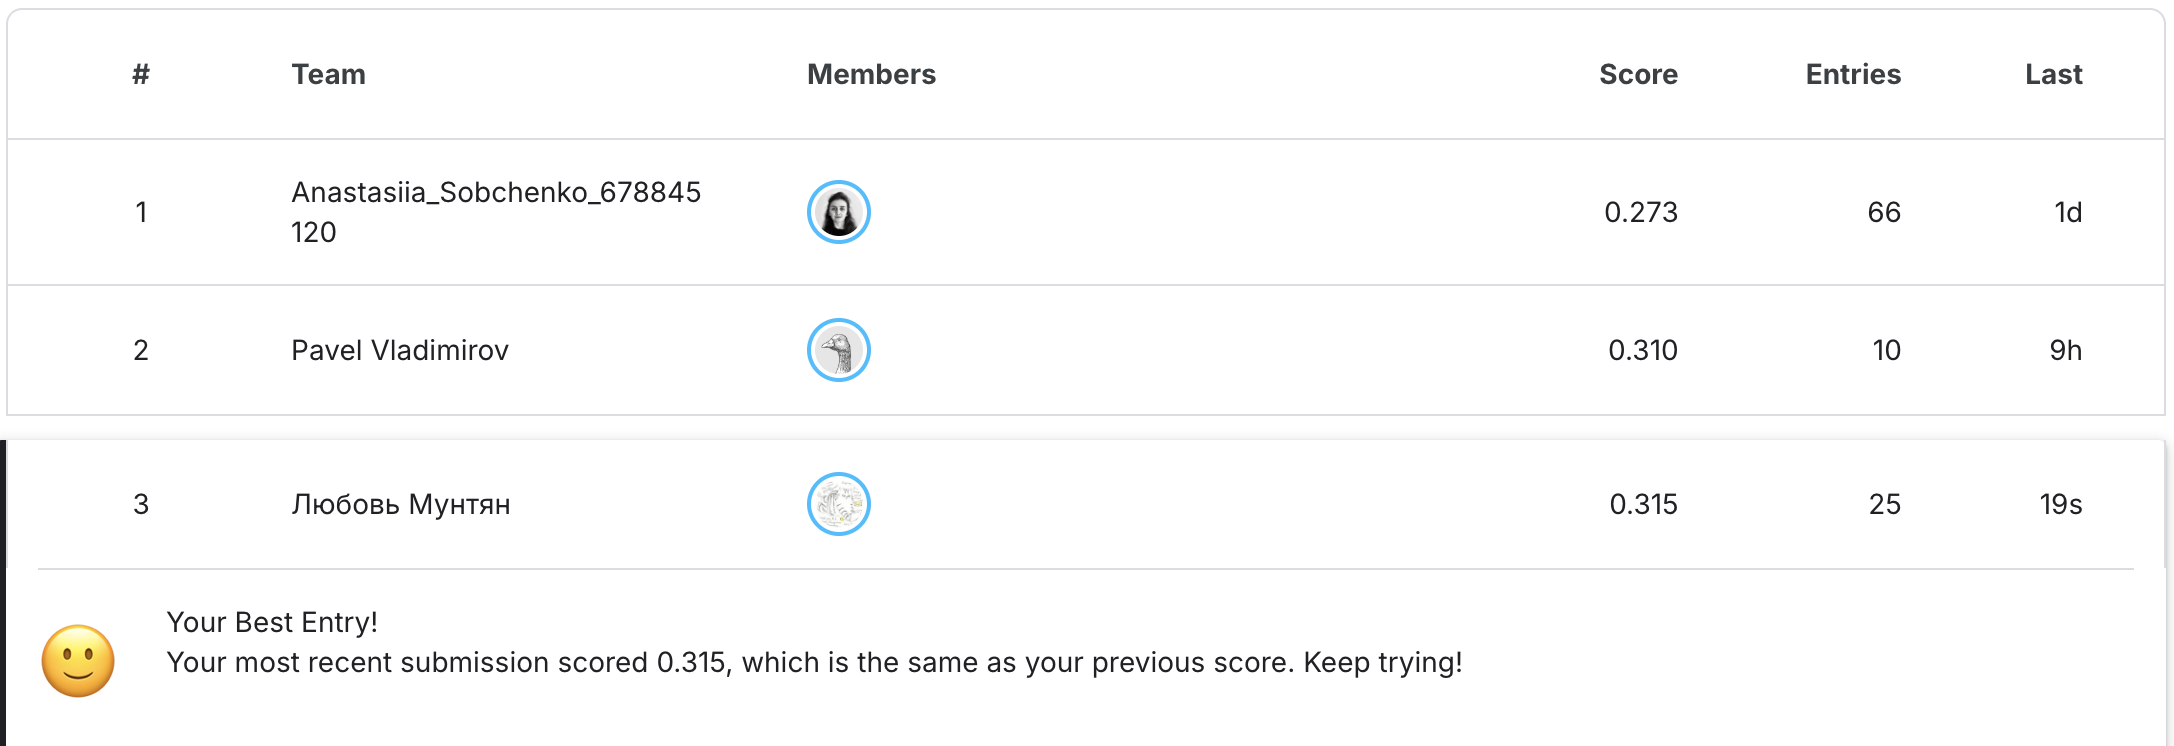

А если б сдала раньше, был бы эпичный топ-1, хоть и с худшим скором

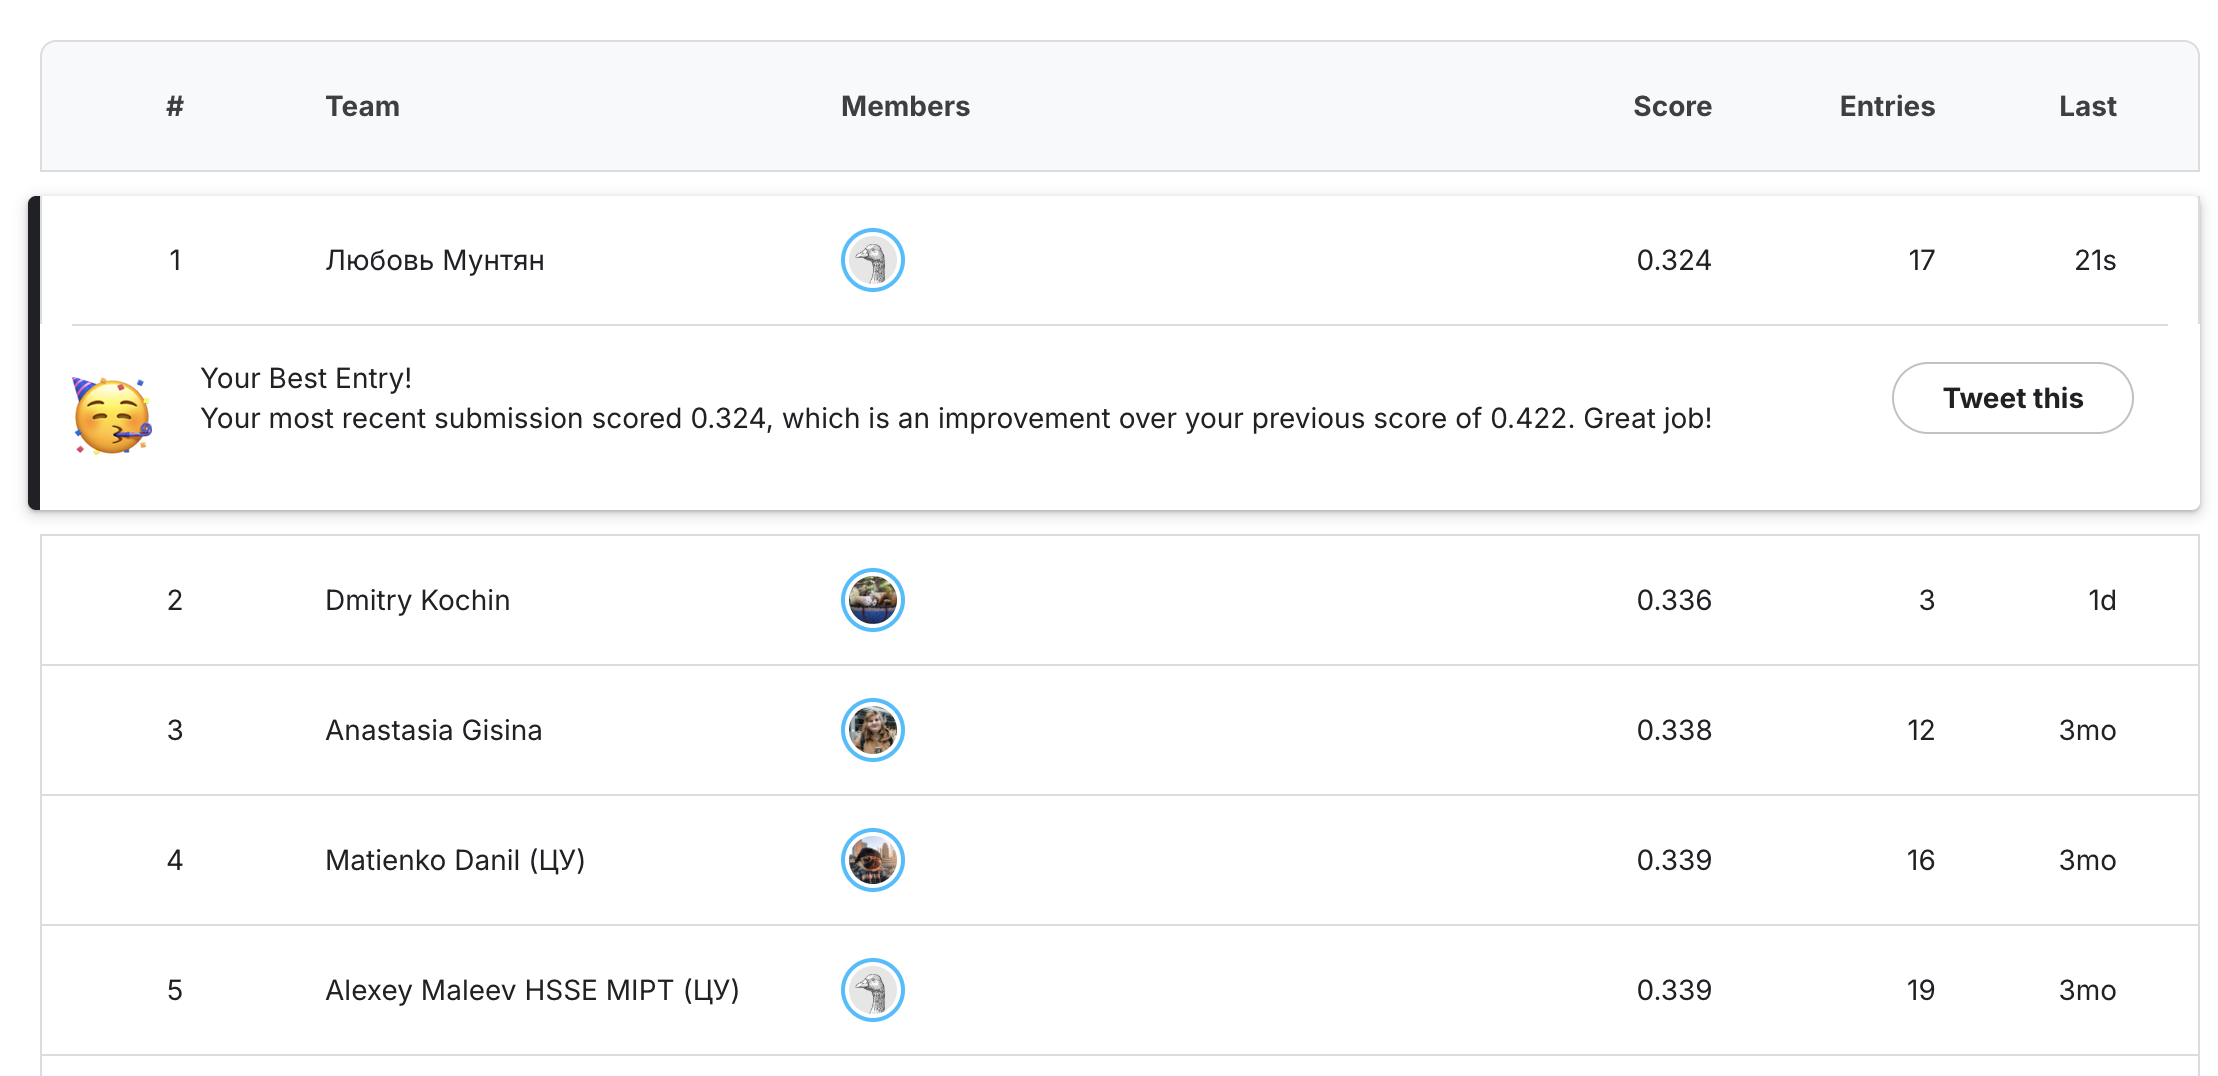